# 02 Preprocessing

Standardize raw painting images to clean 768 × 768 PNG files using resize and center crop.

In [6]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Source folder:", SRC_DIR)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source folder: D:\Masters\FH\Thesis\painting-restoration-eval\src


In [7]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from restoration_eval.paths import (
    RAW_IMAGES_DIR,
    RAW_METADATA_PATH,
    CLEAN_DIR,
    PROCESSED_METADATA_DIR,
    PROCESSED_CLEAN_METADATA_PATH,
    ensure_directories,
)
from restoration_eval.preprocessing import preprocess_images, build_processed_metadata

ensure_directories()

TARGET_SIZE = 768
metadata = pd.read_csv(RAW_METADATA_PATH)
metadata.columns = metadata.columns.str.strip()

display(metadata)
print("Clean output folder:", CLEAN_DIR)

,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,filename
0,p001,portrait,Portrait of a Man,Frans Hals,early 1650s,Dutch Golden Age,Oil on canvas,The Met,https://www.metmuseum.org/art/collection/searc...,Public Domain,p001_portrait_hals.jpg
1,p002,landscape,Wall painting: Perseus and Andromeda in landscape,Roman,last decade of the 1st century BCE,Augustan / Roman,Fresco,The Met,https://www.metmuseum.org/art/collection/searc...,Public Domain,p002_landscape_boscotrecase.jpg
2,p003,brushstroke_heavy,Gardanne,Paul Cézanne,[fill from page],Post-Impressionist,Oil on canvas,The Met,https://www.metmuseum.org/art/collection/searc...,Public Domain,p003_cezanne_gardanne.jpg


Clean output folder: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\clean


In [8]:
processed_df = preprocess_images(
    metadata=metadata,
    raw_images_dir=RAW_IMAGES_DIR,
    clean_output_dir=CLEAN_DIR,
    target_size=TARGET_SIZE,
)

display(processed_df)

,painting_id,raw_filename,processed_filename,processed_width,processed_height,processed_path
0,p001,p001_portrait_hals.jpg,p001_clean.png,768,768,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p002,p002_landscape_boscotrecase.jpg,p002_clean.png,768,768,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p003,p003_cezanne_gardanne.jpg,p003_clean.png,768,768,D:\Masters\FH\Thesis\painting-restoration-eval...


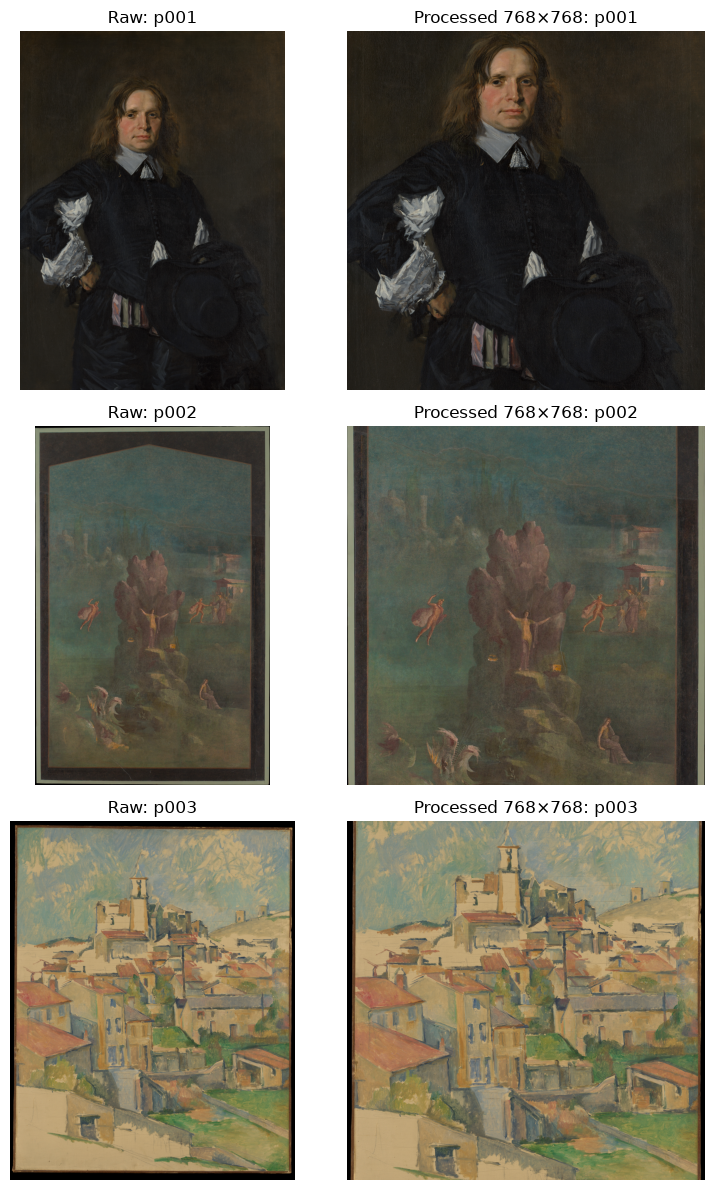

In [9]:
fig, axes = plt.subplots(len(metadata), 2, figsize=(8, 12))

if len(metadata) == 1:
    axes = [axes]

for i, (_, row) in enumerate(metadata.iterrows()):
    raw_path = RAW_IMAGES_DIR / row["filename"]
    processed_path = CLEAN_DIR / f"{row['painting_id']}_clean.png"

    with Image.open(raw_path) as raw_img:
        raw_img = raw_img.convert("RGB")

    with Image.open(processed_path) as processed_img:
        processed_img = processed_img.convert("RGB")

    axes[i, 0].imshow(raw_img)
    axes[i, 0].set_title(f"Raw: {row['painting_id']}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(processed_img)
    axes[i, 1].set_title(f"Processed {TARGET_SIZE}×{TARGET_SIZE}: {row['painting_id']}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [10]:
processed_metadata = build_processed_metadata(metadata, processed_df)
PROCESSED_METADATA_DIR.mkdir(parents=True, exist_ok=True)
processed_metadata.to_csv(PROCESSED_CLEAN_METADATA_PATH, index=False)

print("Saved:", PROCESSED_CLEAN_METADATA_PATH)
display(processed_metadata)

Saved: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_processed_clean.csv


,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,filename,processed_filename,processed_width,processed_height
0,p001,portrait,Portrait of a Man,Frans Hals,early 1650s,Dutch Golden Age,Oil on canvas,The Met,https://www.metmuseum.org/art/collection/searc...,Public Domain,p001_portrait_hals.jpg,p001_clean.png,768,768
1,p002,landscape,Wall painting: Perseus and Andromeda in landscape,Roman,last decade of the 1st century BCE,Augustan / Roman,Fresco,The Met,https://www.metmuseum.org/art/collection/searc...,Public Domain,p002_landscape_boscotrecase.jpg,p002_clean.png,768,768
2,p003,brushstroke_heavy,Gardanne,Paul Cézanne,[fill from page],Post-Impressionist,Oil on canvas,The Met,https://www.metmuseum.org/art/collection/searc...,Public Domain,p003_cezanne_gardanne.jpg,p003_clean.png,768,768
